# Blue Archive ガチャシミュレーション — PU1 / PU2・まとめ引き対応版

## 主な機能

- 開催中の募集を **PU1** と **PU2** に区別
- `initial_banner` で最初に引く募集を選択可能
- PU1キャラ・PU2キャラの獲得数を個別に積算
- PU1募集から開始し、任意の関数条件でPU2募集へ切替可能
- `pulls_per_batch` で1回にまとめて引く回数を設定可能
- まとめ引き中は、停止条件とPU切替条件を評価しない
- バッチ終了後に停止条件と切替条件を評価
- PU1→PU2切替時もチャージを引き継ぐ
- 現在引いている募集の対象PUを引いた場合のみチャージをリセット
- 100チャージ・200チャージ保証は、現在引いている募集の対象PUに適用


In [2]:
from __future__ import annotations

from dataclasses import dataclass, field
from enum import Enum, auto
from typing import Callable, Sequence
import random
import statistics

import matplotlib.pyplot as plt


## 1. 列挙型・設定・状態

In [ ]:
class Banner(Enum):
    PU1 = auto()
    PU2 = auto()


class CharacterType(Enum):
    STAR1 = auto()
    STAR2 = auto()
    STAR3_OTHER = auto()
    PU1 = auto()
    PU2 = auto()


@dataclass(frozen=True)
class GachaConfig:
    pickup_rate: float = 0.007
    other_pickup_rate: float = 0.023 / 100
    star3_rate: float = 0.03
    star2_or_higher_rate: float = 0.215

    use_new_system: bool = True
    initial_charge: int = 0
    initial_banner: Banner = Banner.PU1

    # 1回の操作でまとめて引く回数。
    # 1なら単発、10なら10連。
    pulls_per_batch: int = 10

    charge_100_pickup_rate: float = 0.5
    charge_star3_threshold: int = 100
    charge_pickup_threshold: int = 200

    def __post_init__(self):
        probs = {
            "pickup_rate": self.pickup_rate,
            "other_pickup_rate": self.other_pickup_rate,
            "star3_rate": self.star3_rate,
            "star2_or_higher_rate": self.star2_or_higher_rate,
            "charge_100_pickup_rate": self.charge_100_pickup_rate,
        }

        for name, value in probs.items():
            if not 0 <= value <= 1:
                raise ValueError(f"{name} must be between 0 and 1.")

        if self.pickup_rate + self.other_pickup_rate > self.star3_rate:
            raise ValueError(
                "pickup_rate + other_pickup_rate must not exceed star3_rate."
            )

        if self.star3_rate > self.star2_or_higher_rate:
            raise ValueError(
                "star3_rate must not exceed star2_or_higher_rate."
            )

        if not 0 <= self.initial_charge < self.charge_pickup_threshold:
            raise ValueError(
                "initial_charge must be between 0 and "
                "charge_pickup_threshold - 1."
            )

        if self.pulls_per_batch <= 0:
            raise ValueError("pulls_per_batch must be positive.")


@dataclass(frozen=True)
class PullResult:
    pull_index: int
    batch_index: int
    position_in_batch: int
    banner: Banner
    character_type: CharacterType
    by_charge: bool
    charge_before_pull: int
    charge_after_pull: int

    @property
    def is_star3(self):
        return self.character_type in {
            CharacterType.STAR3_OTHER,
            CharacterType.PU1,
            CharacterType.PU2,
        }


@dataclass
class SimulationState:
    pull_count: int = 0
    batch_count: int = 0
    charge: int = 0
    current_banner: Banner = Banner.PU1

    pu1_count: int = 0
    pu2_count: int = 0
    star3_count: int = 0

    pu1_banner_pull_count: int = 0
    pu2_banner_pull_count: int = 0

    banner_switch_count: int = 0
    switched_to_pu2: bool = False

    history: list[PullResult] = field(default_factory=list)


@dataclass(frozen=True)
class SimulationResult:
    pull_count: int
    batch_count: int
    final_charge: int
    final_banner: Banner

    pu1_count: int
    pu2_count: int
    star3_count: int

    pu1_banner_pull_count: int
    pu2_banner_pull_count: int

    banner_switch_count: int
    switched_to_pu2: bool

    history: tuple[PullResult, ...]

    @classmethod
    def from_state(cls, state):
        return cls(
            pull_count=state.pull_count,
            batch_count=state.batch_count,
            final_charge=state.charge,
            final_banner=state.current_banner,
            pu1_count=state.pu1_count,
            pu2_count=state.pu2_count,
            star3_count=state.star3_count,
            pu1_banner_pull_count=state.pu1_banner_pull_count,
            pu2_banner_pull_count=state.pu2_banner_pull_count,
            banner_switch_count=state.banner_switch_count,
            switched_to_pu2=state.switched_to_pu2,
            history=tuple(state.history),
        )


## 2. ガチャエンジン

In [4]:
class GachaEngine:
    def __init__(self, config, rng=None):
        self.config = config
        self.rng = rng if rng is not None else random.Random()

    @staticmethod
    def target_character(banner):
        return (
            CharacterType.PU1
            if banner is Banner.PU1
            else CharacterType.PU2
        )

    @staticmethod
    def other_pickup_character(banner):
        return (
            CharacterType.PU2
            if banner is Banner.PU1
            else CharacterType.PU1
        )

    def _draw_normal(self, banner):
        x = self.rng.random()

        if x < self.config.pickup_rate:
            return self.target_character(banner)

        if x < self.config.pickup_rate + self.config.other_pickup_rate:
            return self.other_pickup_character(banner)

        if x < self.config.star3_rate:
            return CharacterType.STAR3_OTHER

        if x < self.config.star2_or_higher_rate:
            return CharacterType.STAR2

        return CharacterType.STAR1

    def _draw_with_charge(self, state):
        if not self.config.use_new_system:
            return self._draw_normal(state.current_banner), False

        next_charge = state.charge + 1

        if next_charge == self.config.charge_pickup_threshold:
            return self.target_character(state.current_banner), True

        if next_charge == self.config.charge_star3_threshold:
            if self.rng.random() < self.config.charge_100_pickup_rate:
                return self.target_character(state.current_banner), True
            return self.other_pickup_character(state.current_banner), True

        return self._draw_normal(state.current_banner), False

    def pull(self, state, batch_index, position_in_batch):
        banner = state.current_banner
        charge_before = state.charge

        character_type, by_charge = self._draw_with_charge(state)

        state.pull_count += 1
        state.charge += 1

        if banner is Banner.PU1:
            state.pu1_banner_pull_count += 1
        else:
            state.pu2_banner_pull_count += 1

        if character_type in {
            CharacterType.STAR3_OTHER,
            CharacterType.PU1,
            CharacterType.PU2,
        }:
            state.star3_count += 1

        if character_type is CharacterType.PU1:
            state.pu1_count += 1

        if character_type is CharacterType.PU2:
            state.pu2_count += 1

        target_obtained = (
            banner is Banner.PU1
            and character_type is CharacterType.PU1
        ) or (
            banner is Banner.PU2
            and character_type is CharacterType.PU2
        )

        if self.config.use_new_system and target_obtained:
            state.charge = 0

        result = PullResult(
            pull_index=state.pull_count,
            batch_index=batch_index,
            position_in_batch=position_in_batch,
            banner=banner,
            character_type=character_type,
            by_charge=by_charge,
            charge_before_pull=charge_before,
            charge_after_pull=state.charge,
        )

        state.history.append(result)
        return result

    def pull_batch(self, state):
        """現在の募集を pulls_per_batch 回まとめて引く。

        バッチ中は current_banner を変更せず、
        停止条件・切替条件も評価しない。
        """
        state.batch_count += 1
        batch_index = state.batch_count

        batch_results = []

        for position in range(1, self.config.pulls_per_batch + 1):
            result = self.pull(
                state=state,
                batch_index=batch_index,
                position_in_batch=position,
            )
            batch_results.append(result)

        return batch_results


## 3. 終了条件とPU1→PU2切替条件

In [5]:
StopCondition = Callable[[SimulationState], bool]
SwitchCondition = Callable[[SimulationState], bool]


def stop_at_pull_count(max_pulls):
    """合計連数が指定値以上なら終了。

    まとめ引きの場合、指定値を超えることがある。
    例: 10連単位で95連以上を条件にすると、100連で終了。
    """
    def condition(state):
        return state.pull_count >= max_pulls
    return condition


def stop_at_batch_count(max_batches):
    def condition(state):
        return state.batch_count >= max_batches
    return condition


def stop_when_both_pickups_obtained(state):
    return state.pu1_count >= 1 and state.pu2_count >= 1


def stop_on_pu1_count(target_count):
    def condition(state):
        return state.pu1_count >= target_count
    return condition


def stop_on_pu2_count(target_count):
    def condition(state):
        return state.pu2_count >= target_count
    return condition


def any_condition(*conditions):
    def condition(state):
        return any(fn(state) for fn in conditions)
    return condition


def all_conditions(*conditions):
    def condition(state):
        return all(fn(state) for fn in conditions)
    return condition


def switch_when_pu1_obtained(state):
    return state.pu1_count >= 1


def switch_after_pu1_banner_pulls(max_pulls):
    """PU1募集の累積連数が指定値以上ならPU2へ。

    まとめ引きではバッチ終了後にのみ評価される。
    """
    def condition(state):
        return state.pu1_banner_pull_count >= max_pulls
    return condition


def switch_when_pu1_obtained_or_limit(max_pulls):
    def condition(state):
        return (
            state.pu1_count >= 1
            or state.pu1_banner_pull_count >= max_pulls
        )
    return condition


def never_switch(state):
    return False


## 4. まとめ引き時の判定順序

1. 現在選択中の募集を `pulls_per_batch` 回すべて引く  
2. バッチ終了後に終了条件を評価する  
3. 終了しない場合だけPU1→PU2切替条件を評価する  
4. 切替条件を満たした場合、次のバッチからPU2募集を引く  

したがって、10連の3回目でPU1を引いても、残り7回はPU1募集を引きます。
また、3回目で終了条件を満たしても、10回目まで引いてから終了します。


## 5. シミュレーション

In [6]:
def apply_banner_switch(state, switch_condition):
    if state.current_banner is not Banner.PU1:
        return

    if switch_condition(state):
        state.current_banner = Banner.PU2
        state.banner_switch_count += 1
        state.switched_to_pu2 = True


def simulate_once(
    engine,
    stop_condition,
    switch_condition=never_switch,
    safety_max_batches=100_000,
):
    state = SimulationState(
        charge=engine.config.initial_charge,
        current_banner=engine.config.initial_banner,
    )

    # 初期状態では終了条件を先に評価する。
    while not stop_condition(state):
        if state.batch_count >= safety_max_batches:
            raise RuntimeError("safety_max_batches reached.")

        # バッチ中は終了・切替判定を行わない。
        engine.pull_batch(state)

        # バッチ終了後、まず終了条件を評価。
        if stop_condition(state):
            break

        # 終了しない場合だけ、次バッチ用の募集を切替。
        apply_banner_switch(state, switch_condition)

    return SimulationResult.from_state(state)


def simulate_many(
    config,
    n_simulations,
    stop_condition,
    switch_condition=never_switch,
    seed=42,
    safety_max_batches=100_000,
):
    if n_simulations <= 0:
        raise ValueError("n_simulations must be positive.")

    rng = random.Random(seed)
    engine = GachaEngine(config, rng)

    return [
        simulate_once(
            engine=engine,
            stop_condition=stop_condition,
            switch_condition=switch_condition,
            safety_max_batches=safety_max_batches,
        )
        for _ in range(n_simulations)
    ]


## 6. 統計量

In [7]:
def _require_results(results):
    if not results:
        raise ValueError("results must not be empty.")


def summarize_results(results):
    _require_results(results)
    n = len(results)

    return {
        "PU1入手率": sum(r.pu1_count >= 1 for r in results) / n,
        "PU2入手率": sum(r.pu2_count >= 1 for r in results) / n,
        "PU1・PU2両方の入手率": sum(
            r.pu1_count >= 1 and r.pu2_count >= 1
            for r in results
        ) / n,
        "平均PU1人数": statistics.fmean(
            r.pu1_count for r in results
        ),
        "平均PU2人数": statistics.fmean(
            r.pu2_count for r in results
        ),
        "平均★3人数": statistics.fmean(
            r.star3_count for r in results
        ),
        "平均連数": statistics.fmean(
            r.pull_count for r in results
        ),
        "平均バッチ数": statistics.fmean(
            r.batch_count for r in results
        ),
        "平均PU1募集連数": statistics.fmean(
            r.pu1_banner_pull_count for r in results
        ),
        "平均PU2募集連数": statistics.fmean(
            r.pu2_banner_pull_count for r in results
        ),
        "PU2募集への切替率": sum(
            r.switched_to_pu2 for r in results
        ) / n,
    }


def print_summary(summary):
    for name, value in summary.items():
        if "率" in name or "確率" in name:
            print(f"{name}: {value:.4%}")
        else:
            print(f"{name}: {value:.4f}")


## 7. 可視化

In [8]:
def plot_pull_histogram(results, bins=40):
    values = [r.pull_count for r in results]

    plt.figure(figsize=(9, 5))
    plt.hist(values, bins=bins)
    plt.xlabel("Total pull count")
    plt.ylabel("Frequency")
    plt.title("Distribution of total pull counts")
    plt.tight_layout()
    plt.show()


def plot_pickup_histogram(results, pickup):
    if pickup is CharacterType.PU1:
        values = [r.pu1_count for r in results]
        label = "PU1"
    elif pickup is CharacterType.PU2:
        values = [r.pu2_count for r in results]
        label = "PU2"
    else:
        raise ValueError("pickup must be PU1 or PU2.")

    bins = [
        x - 0.5
        for x in range(min(values), max(values) + 2)
    ]

    plt.figure(figsize=(9, 5))
    plt.hist(values, bins=bins)
    plt.xlabel(f"Number of {label}")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {label} counts")
    plt.tight_layout()
    plt.show()


## 8. 動作確認

In [18]:
def run_sanity_checks():
    # 常に現在募集のPUが出る設定。
    config = GachaConfig(
        pickup_rate=1.0,
        other_pickup_rate=0.0,
        star3_rate=1.0,
        star2_or_higher_rate=1.0,
        initial_banner=Banner.PU1,
        pulls_per_batch=10,
    )

    result = simulate_once(
        engine=GachaEngine(config, random.Random(1)),
        stop_condition=stop_when_both_pickups_obtained,
        switch_condition=switch_when_pu1_obtained,
    )

    # 1バッチ目は途中でPU1を引いても10回すべてPU1募集。
    assert result.pu1_banner_pull_count == 10

    # 1バッチ終了後にPU2へ切替し、
    # 2バッチ目も10回すべてPU2募集。
    assert result.pu2_banner_pull_count == 10
    assert result.pull_count == 20
    assert result.batch_count == 2

    assert result.pu1_count == 10
    assert result.pu2_count == 10
    assert result.switched_to_pu2 is True

    # まとめ引きの途中で停止条件を満たしても、
    # バッチ全体を引き切る。
    single_banner_result = simulate_once(
        engine=GachaEngine(config, random.Random(1)),
        stop_condition=stop_on_pu1_count(1),
        switch_condition=never_switch,
    )

    assert single_banner_result.pull_count == 10
    assert single_banner_result.pu1_count == 10

    print("All sanity checks passed.")


run_sanity_checks()


All sanity checks passed.


## 9. 実行例

In [19]:
config = GachaConfig(
    pickup_rate=0.007,
    other_pickup_rate=0.00022115,
    star3_rate=0.03,
    star2_or_higher_rate=0.215,
    use_new_system=True,
    initial_charge=0,
    initial_banner=Banner.PU1,

    # 1なら単発、10なら10連、20なら20回単位。
    pulls_per_batch=1,
)

N_SIMULATIONS = 100_000
SEED = 42

# PU1を引いたバッチの終了後、PU2へ切替。
switch_condition = switch_when_pu1_obtained

# PU1・PU2を両方引くか、400連以上になったバッチで終了。
stop_condition = any_condition(
    stop_when_both_pickups_obtained,
    stop_at_pull_count(400),
)

results = simulate_many(
    config=config,
    n_simulations=N_SIMULATIONS,
    stop_condition=stop_condition,
    switch_condition=switch_condition,
    seed=SEED,
)

summary = summarize_results(results)
print_summary(summary)


PU1入手率: 100.0000%
PU2入手率: 100.0000%
PU1・PU2両方の入手率: 100.0000%
平均PU1人数: 1.1985
平均PU2人数: 1.0096
平均★3人数: 5.7653
平均連数: 157.2096
平均バッチ数: 157.2096
平均PU1募集連数: 90.2595
平均PU2募集連数: 66.9502
PU2募集への切替率: 74.1830%


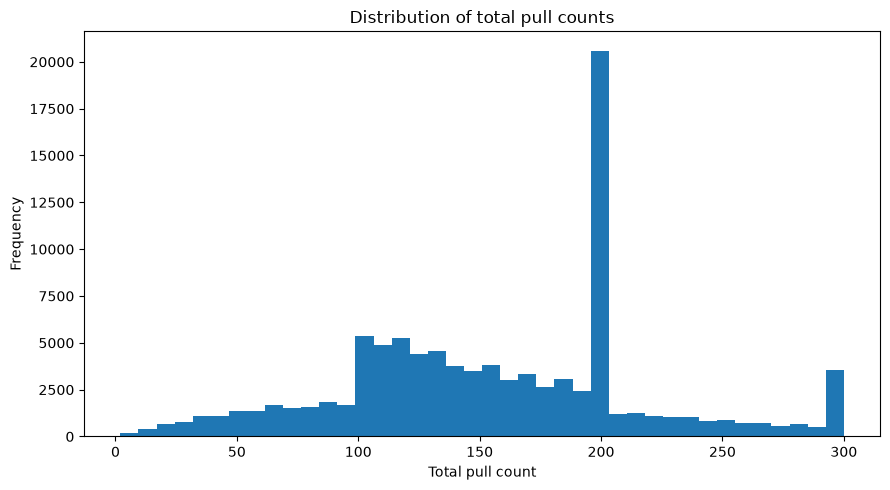

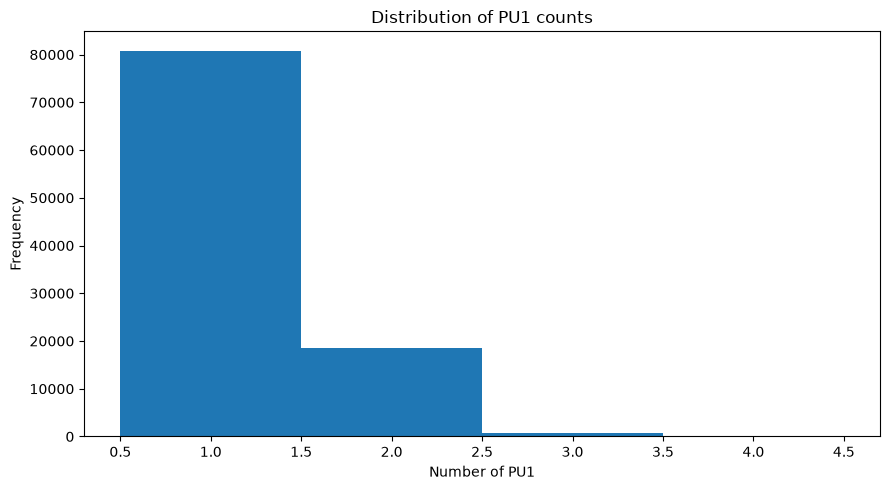

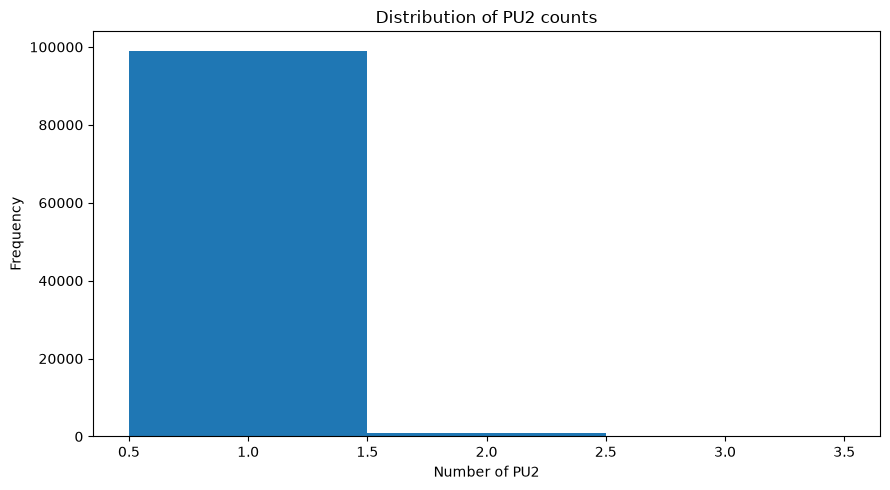

In [20]:
plot_pull_histogram(results)
plot_pickup_histogram(results, CharacterType.PU1)
plot_pickup_histogram(results, CharacterType.PU2)


## 10. まとめ引き回数の変更例

```python
# 単発
config = GachaConfig(pulls_per_batch=1)

# 10連
config = GachaConfig(pulls_per_batch=10)

# 20回単位
config = GachaConfig(pulls_per_batch=20)
```

`stop_at_pull_count(95)` を10連で使用すると、90連終了時点では条件を満たさないため次の10連を引き、100連で終了します。
